# IT5006 - Operational Capacity EDA
## Delivery Timing, Capacity Strain & Fulfilment Pipeline Analysis

**Contributor:** Chai Winnie
**Extends:** `IT5006-Olist_Getting_Started.ipynb` (continues from the consolidated dataset built in that notebook's Section 3)

This notebook explores whether delivery delay is purely a per-order attribute, or partly a
**capacity/throughput problem** that shows up in operational patterns: weekly volume, purchase
timing, freight economics, backlog, and how Olist's own delivery promise behaves under load.
These findings feed the team's candidate problem: predicting delivery lead time (regression) and
classifying orders as late vs. on-time (classification).

---
## 1. Environment Setup & Data Loading

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

mkdir -p failed for path /Users/joshualum/.matplotlib: [Errno 1] Operation not permitted: '/Users/joshualum/.matplotlib'


Matplotlib created a temporary cache directory at /var/folders/lh/h9px96k96s33hykt549wrwv00000gn/T/matplotlib-h1c8haf4 because there was an issue with the default path (/Users/joshualum/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


pandas: 3.0.6
numpy: 2.5.3


In [2]:
# Find the repository data/ folder from the root or this notebook folder.
from pathlib import Path

DATA_DIR = next(
    (root / "data" for root in (Path.cwd(), *Path.cwd().parents)
     if (root / "data" / "olist_orders_dataset.csv").is_file()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find the repository data/ directory")
print(f"Data directory found: {DATA_DIR}")

Data directory found: /Users/joshualum/Documents/VSCode/IT5006_Grp_6/data


In [3]:
# Load the tables this notebook needs into a dictionary of DataFrames,
# same pattern as the starter notebook's load_olist_data()
def load_capacity_data(data_dir):
    """Load the consolidated dataset plus the raw orders table (for
    approval/carrier timestamps not present in the consolidated file)."""

    tables = {
        'consolidated': 'smartcommerce_consolidated.csv',
        'orders': 'olist_orders_dataset.csv',
    }

    date_cols = {
        'consolidated': ['order_purchase_timestamp', 'order_delivered_customer_date',
                          'order_estimated_delivery_date'],
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date'],
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows x {data[name].shape[1]} cols")

    return data

olist = load_capacity_data(DATA_DIR)

Loaded consolidated: 112,650 rows x 25 cols


Loaded orders: 99,441 rows x 8 cols


---
## 2. Preparing the Analysis Dataset

The consolidated file already has order-level fields (`delivery_days`, `is_on_time`,
`day_of_week`, price, freight, category). It does **not** have `order_approved_at` or
`order_delivered_carrier_date` (needed to break lead time into processing / handling /
shipping stages), so those two columns are merged in from the raw orders table.

In [4]:
line_items = olist['consolidated']
orders_raw = olist['orders']

TREND_START = pd.Timestamp('2017-01-01')
TREND_END = pd.Timestamp('2018-09-01')

def eligible_deliveries(order_data):
    """Orders with a delivered status and both dates needed for lead-time analysis."""
    return order_data.loc[
        order_data['order_status'].eq('delivered')
        & order_data['order_delivered_customer_date'].notna()
        & order_data['order_estimated_delivery_date'].notna()
    ].copy()

def trim_trend_window(data, date_column):
    return data.loc[data[date_column].ge(TREND_START) & data[date_column].lt(TREND_END)].copy()

orders = line_items.drop_duplicates('order_id')
print(f"Orders (deduped from line items): {len(orders):,}")

eligible = eligible_deliveries(orders)
print(f"Eligible for lead-time analysis (delivered, complete timestamps): {len(eligible):,} "
      f"({len(eligible) / len(orders) * 100:.1f}% of orders)")

Orders (deduped from line items): 98,666
Eligible for lead-time analysis (delivered, complete timestamps): 96,470 (97.8% of orders)


In [5]:
# Merge in the two extra timestamps needed for stage decomposition
STAGE_LABELS = {
    'processing_time': 'Processing (purchase to approval)',
    'handling_time': 'Handling (approval to carrier)',
    'shipping_time': 'Shipping (carrier to customer)',
}
STAGE_KEYS = list(STAGE_LABELS.keys())

stage_cols = ['order_id', 'order_approved_at', 'order_delivered_carrier_date']
stages = orders.merge(orders_raw[stage_cols], on='order_id', how='left')

stages['processing_time'] = (stages['order_approved_at'] - stages['order_purchase_timestamp']).dt.total_seconds() / 86_400
stages['handling_time'] = (stages['order_delivered_carrier_date'] - stages['order_approved_at']).dt.total_seconds() / 86_400
stages['shipping_time'] = (stages['order_delivered_customer_date'] - stages['order_delivered_carrier_date']).dt.total_seconds() / 86_400

# Isolate the two distinct exclusion reasons separately, rather than lumping them together
has_all_4 = stages[['order_approved_at', 'order_delivered_carrier_date',
                     'order_purchase_timestamp', 'order_delivered_customer_date']].notna().all(axis=1)
missing_timestamp_orders = (~has_all_4).sum()

has_both_compared = stages[['order_approved_at', 'order_delivered_carrier_date']].notna().all(axis=1)
carrier_before_approval = (stages.loc[has_both_compared, 'handling_time'] < 0).sum()

valid_stage_mask = has_all_4 & stages[STAGE_KEYS].ge(0).all(axis=1)
stage_clean = stages.loc[valid_stage_mask].copy()

print(f"Orders missing at least one of the 4 required timestamps: {missing_timestamp_orders:,}")
print(f"Orders with carrier handoff recorded before approval: {carrier_before_approval:,} "
      f"(of {has_both_compared.sum():,} with both timestamps present)")
print(f"Orders with valid, complete, non-negative stage durations: {len(stage_clean):,} "
      f"({len(stage_clean) / len(stages) * 100:.1f}% of all orders)")


Orders missing at least one of the 4 required timestamps: 2,205
Orders with carrier handoff recorded before approval: 1,359 (of 97,643 with both timestamps present)
Orders with valid, complete, non-negative stage durations: 95,088 (96.4% of all orders)


**Data quality note:** 1,359 orders have `order_delivered_carrier_date` recorded *before*
`order_approved_at` — a timestamp-logging inconsistency in the source data, not a bug in this
analysis. These are excluded only from stage-decomposition charts (where a negative duration
would be meaningless), and retained everywhere else.

---
## 3. Capacity Strain: Weekly Order Volume vs. Delivery Time

**Question:** Does delivery slow down when order volume spikes, i.e. is delay partly a
capacity/throughput problem rather than purely a per-order attribute?

In [6]:
weekly_trimmed = trim_trend_window(eligible, 'order_purchase_timestamp')
weekly_trimmed = weekly_trimmed.assign(
    period=weekly_trimmed['order_purchase_timestamp'].dt.to_period('W').dt.start_time
)
capacity_series = weekly_trimmed.groupby('period', as_index=False).agg(
    orders=('order_id', 'nunique'),
    median_delivery_days=('delivery_days', 'median'),
)

corr = capacity_series['orders'].corr(capacity_series['median_delivery_days'])
peak_volume_week = capacity_series.loc[capacity_series['orders'].idxmax()]
peak_delay_week = capacity_series.loc[capacity_series['median_delivery_days'].idxmax()]

print(f"Correlation (weekly volume, median delivery days): r = {corr:.2f}")
print(f"Peak volume week: {peak_volume_week['period'].date()} -> {peak_volume_week['orders']:.0f} orders, "
      f"{peak_volume_week['median_delivery_days']:.0f}-day median")
print(f"Peak delay week:  {peak_delay_week['period'].date()} -> {peak_delay_week['orders']:.0f} orders, "
      f"{peak_delay_week['median_delivery_days']:.0f}-day median")

Correlation (weekly volume, median delivery days): r = 0.12
Peak volume week: 2017-11-20 -> 2915 orders, 13-day median
Peak delay week:  2018-01-29 -> 1561 orders, 15-day median


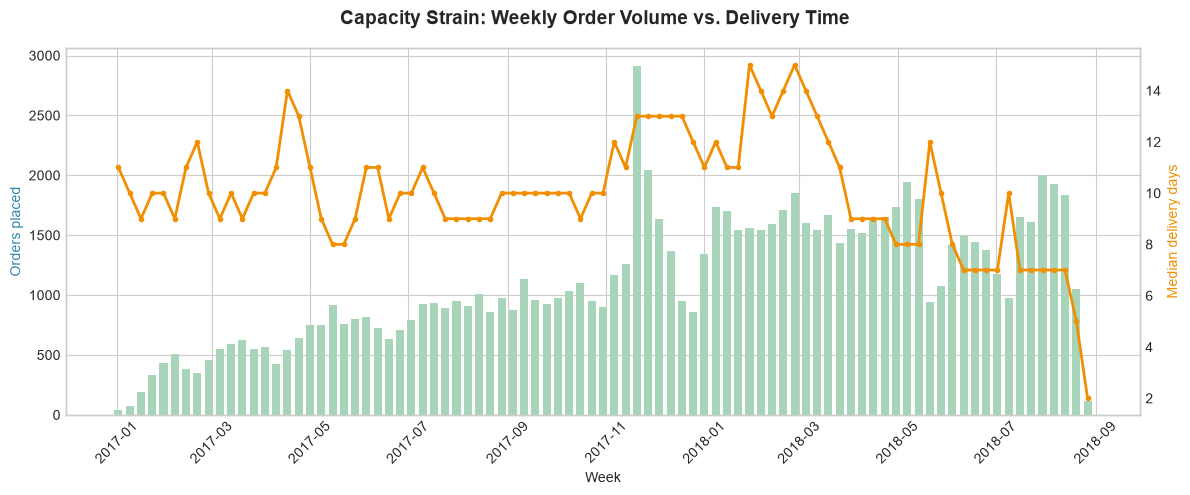

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle('Capacity Strain: Weekly Order Volume vs. Delivery Time', fontsize=14, fontweight='bold')

ax1.bar(capacity_series['period'], capacity_series['orders'], width=5, color='#A8D5BA', label='Orders placed')
ax1.set_xlabel('Week')
ax1.set_ylabel('Orders placed', color='#2E86AB')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(capacity_series['period'], capacity_series['median_delivery_days'], color='#F18F01', linewidth=2, marker='o', markersize=3)
ax2.set_ylabel('Median delivery days', color='#F18F01')
ax2.grid(False)

plt.tight_layout()
plt.show()

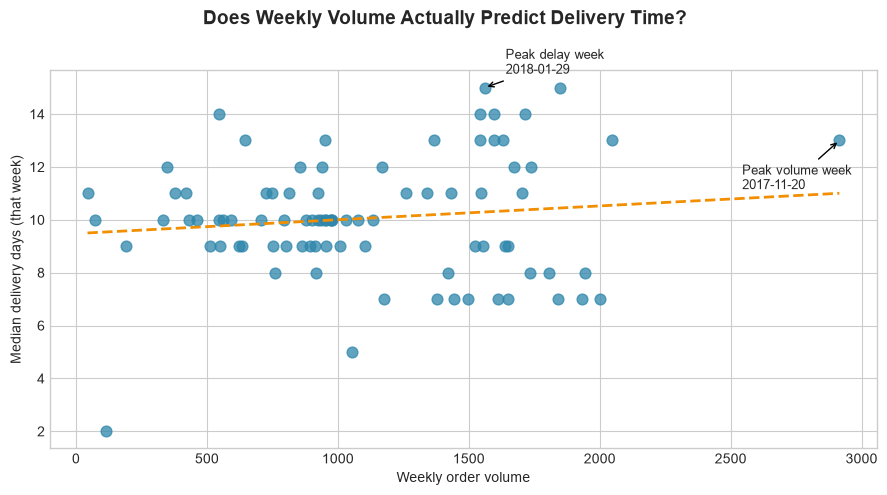

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Does Weekly Volume Actually Predict Delivery Time?', fontsize=14, fontweight='bold')

ax.scatter(capacity_series['orders'], capacity_series['median_delivery_days'], color='#2E86AB', alpha=0.75, s=60)

coeffs = np.polyfit(capacity_series['orders'], capacity_series['median_delivery_days'], 1)
xs = np.linspace(capacity_series['orders'].min(), capacity_series['orders'].max(), 100)
ax.plot(xs, coeffs[0] * xs + coeffs[1], color='#F18F01', linestyle='--', linewidth=2)

ax.annotate(
    f"Peak volume week\n{peak_volume_week['period'].date()}",
    (peak_volume_week['orders'], peak_volume_week['median_delivery_days']),
    textcoords='offset points', xytext=(-70, -35), fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black', lw=1),
)
ax.annotate(
    f"Peak delay week\n{peak_delay_week['period'].date()}",
    (peak_delay_week['orders'], peak_delay_week['median_delivery_days']),
    textcoords='offset points', xytext=(15, 10), fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black', lw=1),
)

ax.set_xlabel('Weekly order volume')
ax.set_ylabel('Median delivery days (that week)')

plt.tight_layout()
plt.show()

**Finding:** Weekly order volume and recorded delivery time have only a weak correlation (r ≈ 0.12). The Nov–Dec 2017 demand spike was followed by six weeks with median delivery times around 11–13 whole days. These cohort-level associations cannot identify the cause of the delay.

---
## 4. Purchase Timing: Day-of-Week x Hour Heatmap

**Question:** Is the moment an order is placed (day/hour) informative about delivery time, even
though it's a free, always-available feature at order time?

In [9]:
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heat_data = eligible.assign(purchase_hour=eligible['order_purchase_timestamp'].dt.hour)
heatmap = heat_data.groupby(['day_of_week', 'purchase_hour'])['delivery_days'].mean().unstack()
heatmap = heatmap.reindex(DAY_ORDER)

by_day = heat_data.groupby('day_of_week')['delivery_days'].mean().reindex(DAY_ORDER).sort_values()
print("Mean delivery days by purchase day-of-week:")
print(by_day.round(2))

Mean delivery days by purchase day-of-week:
day_of_week
Sunday      11.47
Monday      11.53
Tuesday     11.61
Wednesday   11.98
Thursday    12.28
Saturday    12.89
Friday      13.12
Name: delivery_days, dtype: float64


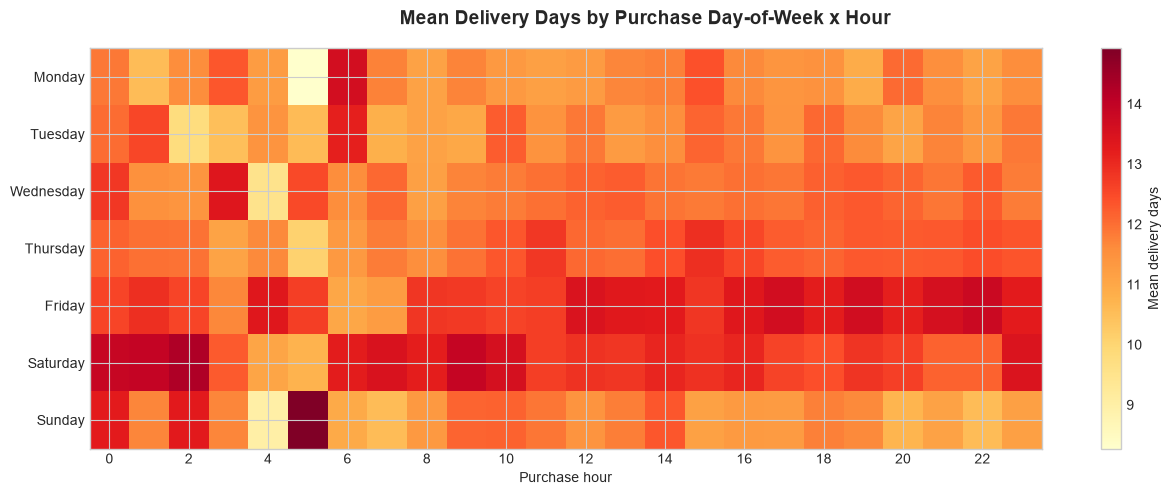

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Mean Delivery Days by Purchase Day-of-Week x Hour', fontsize=14, fontweight='bold')

im = ax.imshow(heatmap.values, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(len(DAY_ORDER)))
ax.set_yticklabels(DAY_ORDER)
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels(range(0, 24, 2))
ax.set_xlabel('Purchase hour')
fig.colorbar(im, ax=ax, label='Mean delivery days')

plt.tight_layout()
plt.show()

**Finding:** Sunday purchases average about 11.5 recorded whole days to delivery, versus 13.1 for Friday purchases. The day-and-hour heatmap is descriptive; further adjustment is needed before attributing the gap to weekend processing.

---
## 5. Which Fulfilment Stage Slows Down for Weekend Purchases?

**Question:** Decomposing the day-of-week effect above into processing / handling / shipping,
does it concentrate in one specific stage?

In [11]:
stage_clean_dow = stage_clean.assign(
    day_of_week=stage_clean['order_purchase_timestamp'].dt.day_name()
)
by_weekday_stage = stage_clean_dow.groupby('day_of_week')[STAGE_KEYS].mean().reindex(DAY_ORDER)
print(by_weekday_stage.round(2))

             processing_time  handling_time  shipping_time
day_of_week                                               
Monday                  0.36           2.38           9.31
Tuesday                 0.34           2.53           9.28
Wednesday               0.34           2.68           9.51
Thursday                0.35           3.04           9.40
Friday                  0.51           3.71           9.38
Saturday                0.56           3.33           9.53
Sunday                  0.41           2.45           9.16


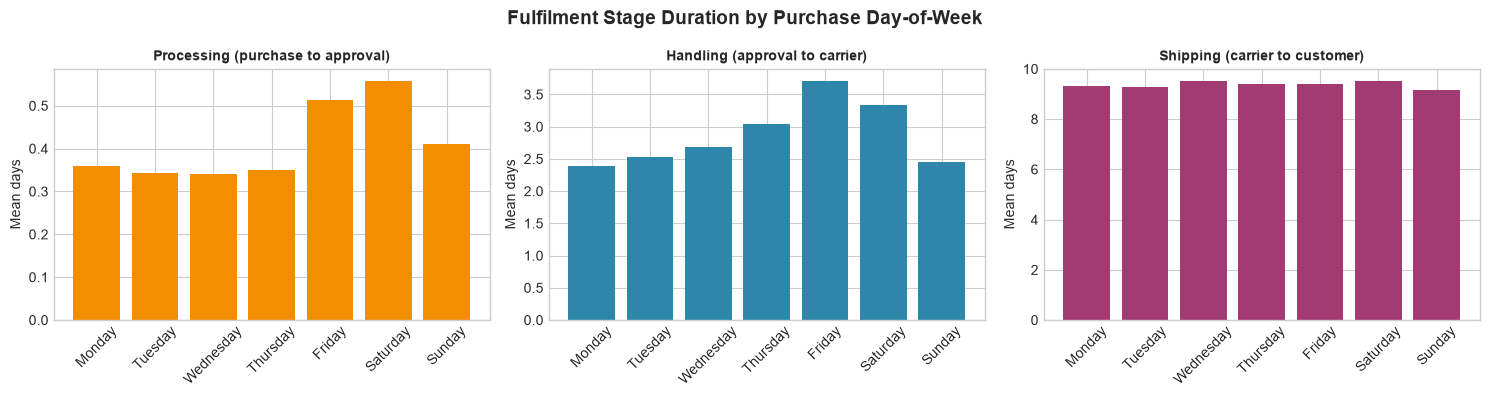

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Fulfilment Stage Duration by Purchase Day-of-Week', fontsize=14, fontweight='bold')
stage_colors = ['#F18F01', '#2E86AB', '#A23B72']

for ax, stage_key, color in zip(axes, STAGE_KEYS, stage_colors):
    ax.bar(DAY_ORDER, by_weekday_stage[stage_key], color=color)
    ax.set_title(STAGE_LABELS[stage_key], fontweight='bold', fontsize=10)
    ax.set_ylabel('Mean days')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Finding:** Mean handling duration (approval to carrier handoff) is higher for Thursday–Saturday purchases than for Sunday–Wednesday purchases, while shipping duration changes less by purchase day. These timestamps locate the observed difference within the recorded stages; they do not identify the underlying warehouse or carrier mechanism.

---
## 6. Freight Cost Efficiency: Freight-to-Price Ratio vs. Late-Rate

**Question:** Does a composite ratio combining distance, weight and carrier pricing (freight
value / price) predict lateness?

In [13]:
order_economics = line_items.groupby('order_id', as_index=False).agg(
    price_sum=('price', 'sum'), freight_sum=('freight_value', 'sum')
)
order_status_cols = line_items.drop_duplicates('order_id')[
    ['order_id', 'order_status', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_on_time']
]
freight_data = order_economics.merge(order_status_cols, on='order_id', how='left')
freight_data = eligible_deliveries(freight_data)
freight_data = freight_data.loc[freight_data['price_sum'] > 0].copy()
freight_data['freight_ratio'] = freight_data['freight_sum'] / freight_data['price_sum']
freight_data['late'] = ~freight_data['is_on_time'].astype(bool)
freight_data['ratio_bucket'] = pd.qcut(freight_data['freight_ratio'], 6, duplicates='drop')

freight_buckets = freight_data.groupby('ratio_bucket', observed=True).agg(
    late_rate=('late', 'mean'), orders=('order_id', 'size')
).reset_index()
freight_buckets['late_rate'] *= 100
freight_buckets['label'] = freight_buckets['ratio_bucket'].apply(lambda i: f"{max(i.left, 0):.2f}-{i.right:.2f}")
print(freight_buckets[['label', 'late_rate', 'orders']].round(2))

        label  late_rate  orders
0   0.00-0.10       6.93   16080
1   0.10-0.16       6.46   16077
2   0.16-0.22       6.67   16099
3   0.22-0.31       6.73   16057
4   0.31-0.49       6.72   16078
5  0.49-21.45       7.13   16079


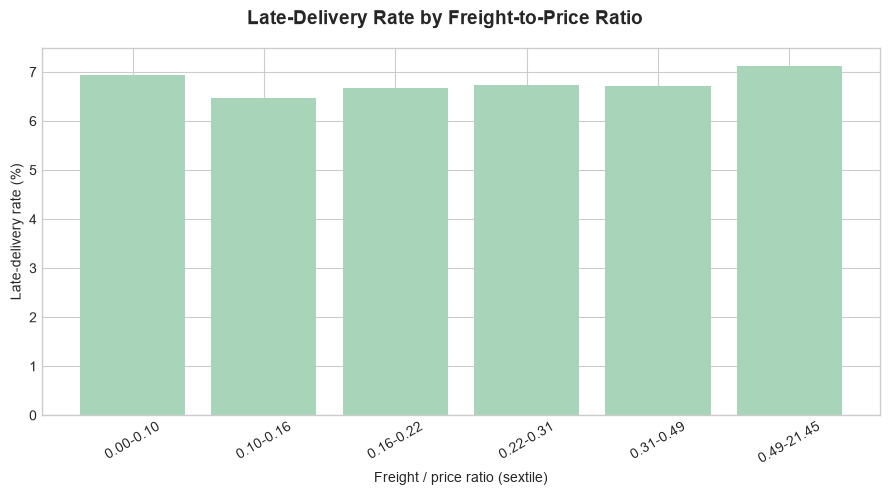

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Late-Delivery Rate by Freight-to-Price Ratio', fontsize=14, fontweight='bold')
ax.bar(freight_buckets['label'], freight_buckets['late_rate'], color='#A8D5BA')
ax.set_xlabel('Freight / price ratio (sextile)')
ax.set_ylabel('Late-delivery rate (%)')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Finding:** Calendar-date late rates span about 6.5–7.1% across the six freight-to-price buckets. This weak separation makes the ratio a limited standalone descriptive signal. Its value as a Phase 2 predictor must be checked out of sample alongside other features.

---
## 7. Backlog: Orders Placed vs. Delivered Over Time

**Question:** Does a cumulative gap between orders placed and orders delivered build up during
high-volume periods, and how long does it take to clear?

In [15]:
placed = weekly_trimmed.groupby('period').size()
placed.name = 'placed'

completed_data = weekly_trimmed.assign(
    completed_period=weekly_trimmed['order_delivered_customer_date'].dt.to_period('W').dt.start_time
)
completed = completed_data.groupby('completed_period').size()
completed.name = 'completed'

backlog = pd.concat([placed, completed], axis=1).fillna(0)
full_index = pd.date_range(backlog.index.min(), backlog.index.max(), freq='W-MON')
backlog = backlog.reindex(full_index, fill_value=0)
backlog.index.name = 'period'
backlog = backlog.reset_index()
backlog['backlog'] = (backlog['placed'] - backlog['completed']).cumsum()

peak_backlog = backlog.loc[backlog['backlog'].idxmax()]
print(f"Peak backlog: {peak_backlog['backlog']:.0f} orders, week of {peak_backlog['period'].date()}")

Peak backlog: 4429 orders, week of 2017-11-27


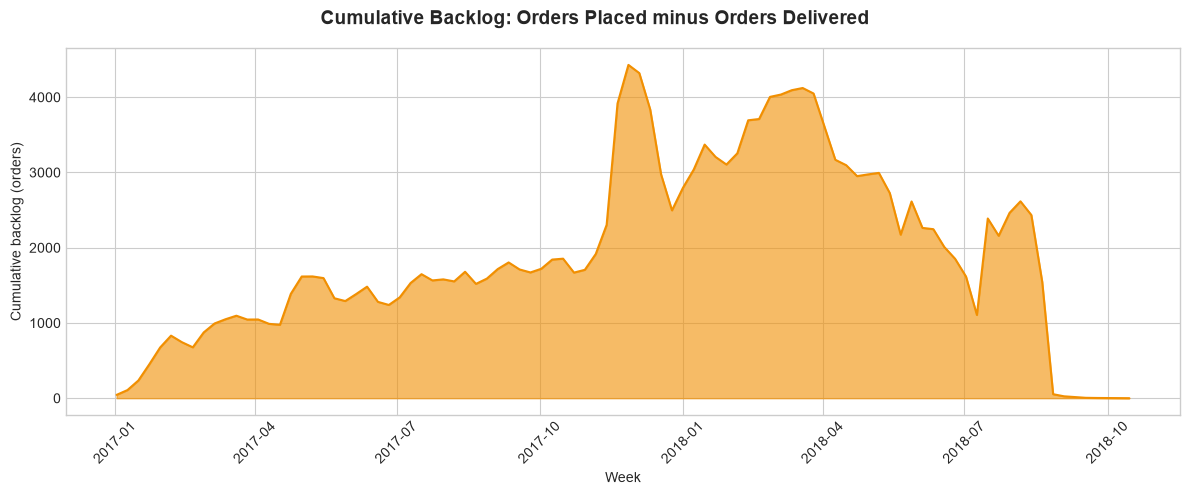

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Cumulative Backlog: Orders Placed minus Orders Delivered', fontsize=14, fontweight='bold')
ax.fill_between(backlog['period'], backlog['backlog'], color='#F18F01', alpha=0.6)
ax.plot(backlog['period'], backlog['backlog'], color='#F18F01', linewidth=1.5)
ax.set_xlabel('Week')
ax.set_ylabel('Cumulative backlog (orders)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Finding:** The retrospective cohort backlog proxy peaks at 4,429 orders in the week of 27 November 2017, one week after the volume peak. It counts eventually delivered orders purchased in the selected period and is not a reconstruction of the marketplace's complete live backlog; it cannot by itself establish a capacity bottleneck.

---
## 8. Does Olist's Own Delivery Promise React to Capacity Strain?

**Question:** Is the "late" label stable over time, or does the promised delivery window itself
drift &mdash; which would mean the classification target for Phase 2 needs careful definition?

In [17]:
promise_data = weekly_trimmed.assign(
    promised_days=(weekly_trimmed['order_estimated_delivery_date'] - weekly_trimmed['order_purchase_timestamp']).dt.total_seconds() / 86_400,
    actual_days=(weekly_trimmed['order_delivered_customer_date'] - weekly_trimmed['order_purchase_timestamp']).dt.total_seconds() / 86_400,
    late=weekly_trimmed['order_delivered_customer_date'].dt.normalize() > weekly_trimmed['order_estimated_delivery_date'].dt.normalize(),
)
promise_series = promise_data.groupby('period', as_index=False).agg(
    mean_promised_days=('promised_days', 'mean'),
    mean_actual_days=('actual_days', 'mean'),
    late_rate=('late', 'mean'),
)
promise_series['late_rate'] *= 100
promise_series['buffer_days'] = promise_series['mean_promised_days'] - promise_series['mean_actual_days']

corr_promise_late = promise_series['buffer_days'].corr(promise_series['late_rate'])
print(f"Correlation (buffer_days, late_rate): r = {corr_promise_late:.2f}")

trailing_8wk = promise_series['mean_actual_days'].rolling(8).mean().shift(1)
corr_trailing = promise_series['mean_promised_days'].corr(trailing_8wk)
print(f"Correlation (promised_days, 8-week trailing actual_days): r = {corr_trailing:.2f}")

Correlation (buffer_days, late_rate): r = -0.57
Correlation (promised_days, 8-week trailing actual_days): r = 0.45


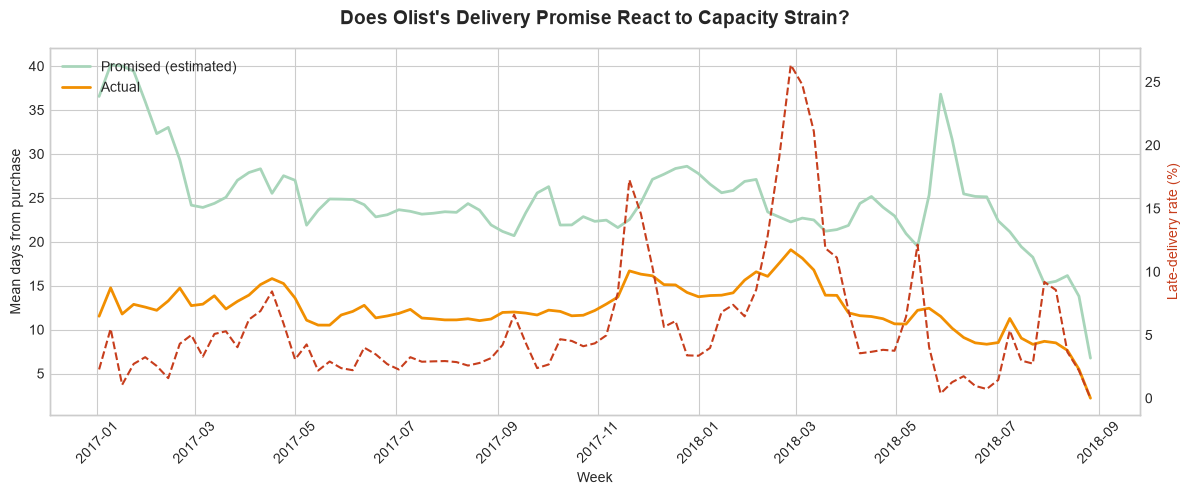

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle("Does Olist's Delivery Promise React to Capacity Strain?", fontsize=14, fontweight='bold')

ax1.plot(promise_series['period'], promise_series['mean_promised_days'], color='#A8D5BA', linewidth=2, label='Promised (estimated)')
ax1.plot(promise_series['period'], promise_series['mean_actual_days'], color='#F18F01', linewidth=2, label='Actual')
ax1.set_xlabel('Week')
ax1.set_ylabel('Mean days from purchase')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(promise_series['period'], promise_series['late_rate'], color='#C73E1D', linewidth=1.5, linestyle='--', label='Late-delivery rate (%)')
ax2.set_ylabel('Late-delivery rate (%)', color='#C73E1D')
ax2.grid(False)

plt.tight_layout()
plt.show()

**Finding:** The promised window widens with a lag after volume spikes (it barely moves
during the Nov 2017 peak week itself, but keeps climbing for weeks afterward). It correlates more
with a several-week trailing average of actual delivery performance than with current-week
backlog, suggesting a slow-reacting historical baseline rather than a live capacity signal.
Since the late/on-time label is defined relative to this promise, a wider promise can lower the
late-rate even if actual delivery isn't getting faster &mdash; a methodological note worth carrying
into how the classification target is defined in Phase 2.

---
## 9. Where Does the Delay Accumulate? Stage Duration Over Time

In [19]:
stage_weekly = trim_trend_window(stage_clean, 'order_purchase_timestamp').assign(
    period=lambda d: d['order_purchase_timestamp'].dt.to_period('W').dt.start_time
)
stage_over_time = stage_weekly.groupby('period')[STAGE_KEYS].mean()

overall_mean = stage_clean[STAGE_KEYS].mean()
print("Overall mean duration per stage (days):")
print(overall_mean.round(2))
print(f"\nShipping share of total lead time: {overall_mean['shipping_time'] / overall_mean.sum() * 100:.0f}%")

Overall mean duration per stage (days):
processing_time   0.40
handling_time     2.85
shipping_time     9.36
dtype: float64

Shipping share of total lead time: 74%


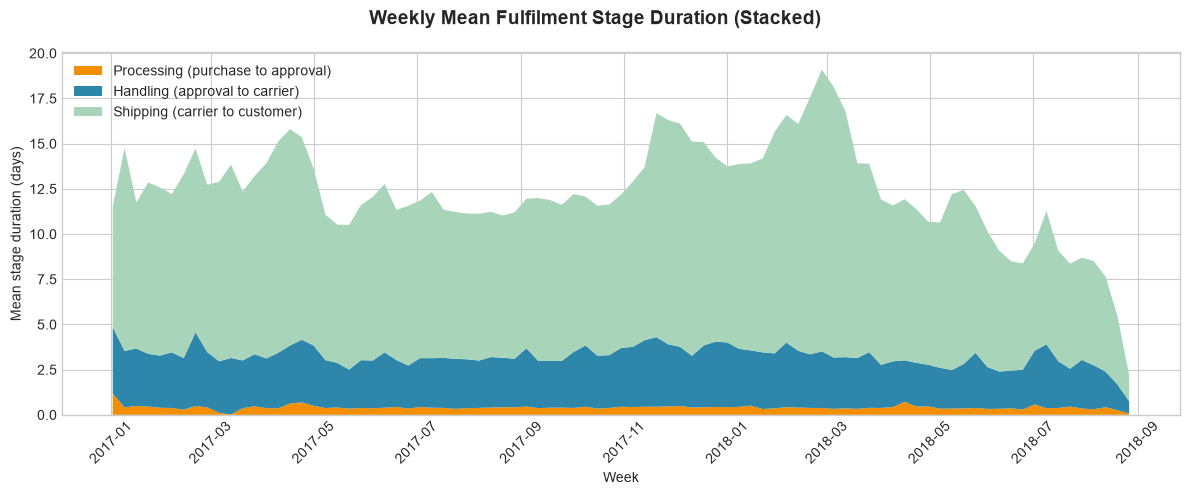

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Weekly Mean Fulfilment Stage Duration (Stacked)', fontsize=14, fontweight='bold')
stage_colors = ['#F18F01', '#2E86AB', '#A8D5BA']

ax.stackplot(stage_over_time.index, [stage_over_time[k] for k in STAGE_KEYS],
             labels=[STAGE_LABELS[k] for k in STAGE_KEYS], colors=stage_colors)
ax.set_xlabel('Week')
ax.set_ylabel('Mean stage duration (days)')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Finding:** Shipping accounts for about 74% of mean recorded lead time, versus roughly 23% for handling and 3% for processing. Weekly shipping duration has the strongest association with concurrent order volume among these stages. That pattern does not establish a carrier-capacity cause because this is observational cohort data.

---
## 10. Key Insights Summary

In [21]:
# Consolidated summary, same list-of-dicts -> DataFrame pattern as the starter notebook's
# schema_summary(), and dict-of-lists -> DataFrame pattern as its kpi_summary
capacity_kpi_summary = pd.DataFrame({
    'Metric': [
        'Volume-vs-delay correlation',
        'Delivery gap: Sunday vs Friday purchase',
        'Weekend handling-stage slowdown',
        'Freight-ratio vs late-rate range',
        'Peak backlog',
        'Promise-buffer vs trailing-actual correlation',
        'Shipping share of total lead time',
    ],
    'Value': [
        f"r = {corr:.2f}",
        f"{by_day.max() - by_day.min():.1f} days",
        f"{by_weekday_stage['handling_time'].max():.1f}d vs {by_weekday_stage['handling_time'].min():.1f}d",
        f"{freight_buckets['late_rate'].min():.1f}% - {freight_buckets['late_rate'].max():.1f}%",
        f"{peak_backlog['backlog']:.0f} orders",
        f"r = {corr_trailing:.2f}",
        f"{overall_mean['shipping_time'] / overall_mean.sum() * 100:.0f}%",
    ],
    'Implication': [
        'Concurrent volume has weak correlation with recorded delay',
        'Purchase timing is a free, zero-cost candidate feature',
        'Handling stage varies by purchase day; mechanism untested',
        'Weak descriptive separation; test predictive value out of sample',
        'Retrospective cohort backlog proxy peaks after demand spike',
        "Estimated window varies over time; target definition matters",
        'Shipping is the longest recorded stage; bottleneck not established',
    ],
})

print("=" * 100)
print("OPERATIONAL CAPACITY - KEY INSIGHTS SUMMARY")
print("=" * 100)
print(capacity_kpi_summary.to_string(index=False))
print("=" * 100)

OPERATIONAL CAPACITY - KEY INSIGHTS SUMMARY
                                       Metric        Value                                                        Implication
                  Volume-vs-delay correlation     r = 0.12         Concurrent volume has weak correlation with recorded delay
      Delivery gap: Sunday vs Friday purchase     1.6 days             Purchase timing is a free, zero-cost candidate feature
              Weekend handling-stage slowdown 3.7d vs 2.4d          Handling stage varies by purchase day; mechanism untested
             Freight-ratio vs late-rate range  6.5% - 7.1%   Weak descriptive separation; test predictive value out of sample
                                 Peak backlog  4429 orders        Retrospective cohort backlog proxy peaks after demand spike
Promise-buffer vs trailing-actual correlation     r = 0.45       Estimated window varies over time; target definition matters
            Shipping share of total lead time          74% Shipping is the

### What this notebook supports

1. The selected cohort's backlog proxy peaks after the November 2017 demand spike; it is not the marketplace's complete live backlog.
2. Purchase day and hour are available early and are candidates for Phase 2 feature testing. The observed day-of-week gap appears mainly in the handling stage, without proving a mechanism.
3. Shipping accounts for about 74% of mean recorded lead time. Its weekly duration is associated with concurrent volume, but causation remains untested.
4. The estimated delivery window varies over time, so classification against Olist's promise needs a clearly defined purchase-time target.

**Candidate problems:** purchase-to-delivery regression and calendar-date late classification. Post-delivery stages and outcomes must be excluded from purchase-time predictors.